![JohnSnowLabs](https://sparknlp.org/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp/blob/master/examples/python/data-preprocessing/SparkNLP_LayoutAligners_Document_Understanding_Demo.ipynb)

# Spark NLP LayoutAligners for Document Understanding

This notebook demonstrates the new `LayoutAlignerForVision` and `LayoutAlignerForText` annotators for multimodal document understanding.

Goal:
1. Align text chunks with nearby images using layout-aware heuristics.
2. Generate image captions from aligned image + prompt pairs.
3. Rebuild semantically richer document text by injecting image meaning in context.

## 1) Why these new aligners matter

`LayoutAlignerForVision` solves a core ingestion problem: extracted text and images are often disconnected after parsing PDFs/DOCX/PPTX.

It creates structured multimodal pairs:
- `aligned_doc`: the text chunk selected by layout proximity
- `aligned_image`: the corresponding image annotation
- `aligned_prompt`: a captioning prompt for a VLM

`LayoutAlignerForText` then merges text and captions back into coherent reading order, so downstream embedding, retrieval, and RAG pipelines keep visual semantics.

## 2) Three practical use cases

### a) Enterprise Revenue Performance Report
Financial reports mix narrative text, KPI tables, and charts. If charts are captioned without local context, answers to business queries can lose numeric intent. Layout alignment anchors each chart to nearby paragraphs before captioning, then fuses both into one searchable text.

### b) Clinical Trial Summary
Trial PDFs include endpoint plots, cohort diagrams, and adverse-event tables. Aligning each visual artifact to adjacent clinical narrative preserves safety/efficacy context and improves precision for medical evidence retrieval.

### c) Cloud Microservices Architecture
Architecture docs combine service descriptions with topology diagrams. Captions grounded by neighboring technical text produce reconstruction that keeps dependency flow, boundaries, and failure-domain semantics for ops and architecture search.

## 3) Setup environment and load PDF data

Prerequisites:
- Spark NLP installed and configured
- Access to PDF files under `pdf_directory`
- Optional GPU for faster `AutoGGUFVisionModel` inference

In [ ]:
base_url = "https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp/examples/python/data-preprocessing/data"

In [ ]:
!mkdir content/pdf-files

In [ ]:
!wget "{base_url}/Document_1_Revenue_Report.pdf" -P content/pdf-files
!wget "{base_url}/pdf-Document_2_Clinical_Trial.pdf" -P content/pdf-files
!wget "{base_url}/text_3_pagesDocument_3_Cloud_Architecture.pdf" -P content/pdf-files

In [ ]:
!apt-get install -y poppler-utils
!pip install pdf2image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (1,832 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


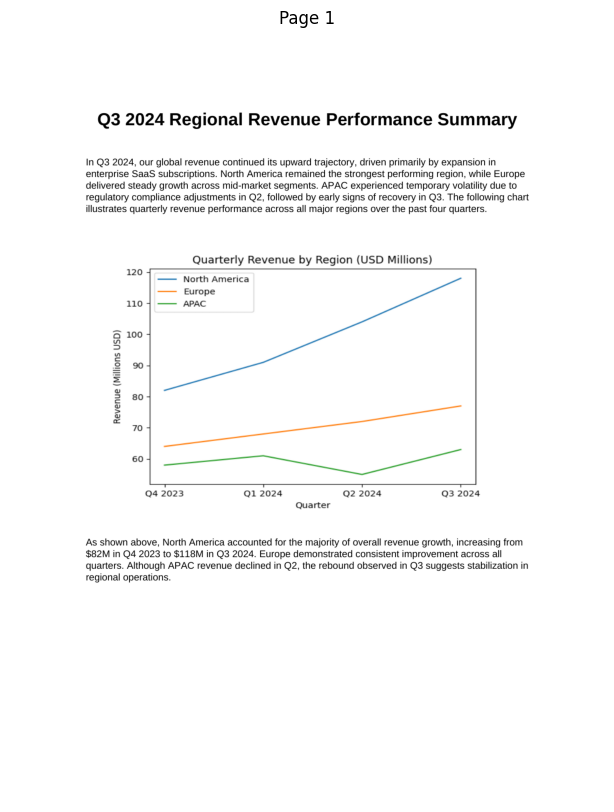

In [ ]:
from pdf2image import convert_from_path
import matplotlib.pyplot as plt

pdf_path = "/content/pdf-files/Document_1_Revenue_Report.pdf"

pages = convert_from_path(pdf_path, dpi=150)

for i, page in enumerate(pages):
    plt.figure(figsize=(8, 10))
    plt.imshow(page)
    plt.axis("off")
    plt.title(f"Page {i+1}")
    plt.show()

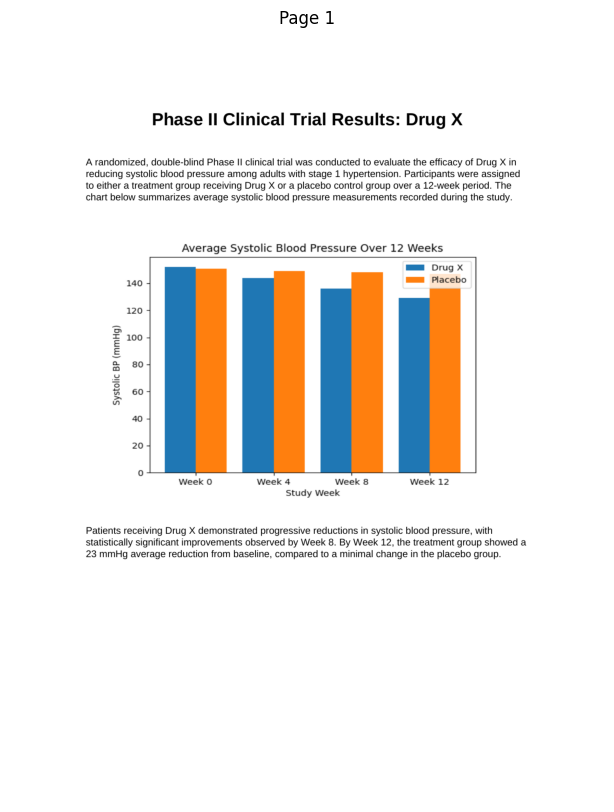

In [ ]:
pdf_path = "/content/pdf-files/Document_2_Clinical_Trial.pdf"

pages = convert_from_path(pdf_path, dpi=150)

for i, page in enumerate(pages):
    plt.figure(figsize=(8, 10))
    plt.imshow(page)
    plt.axis("off")
    plt.title(f"Page {i+1}")
    plt.show()

In [ ]:
!pip uninstall -y dataproc-spark-connect
!pip install pyspark==3.5.7

Found existing installation: dataproc-spark-connect 1.0.2
Uninstalling dataproc-spark-connect-1.0.2:
  Successfully uninstalled dataproc-spark-connect-1.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.4/317.4 MB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 19.3 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.7-py2.py3-none-any.whl size=317907716 sha256=afd3b76eda1f9b5b8a420708c8138b3593ef90f230fb28ac0539db302efab8fb
  Stored in directory: /root/.cache/pip/wheels/f2/d3/02/10ad17f2eeb2cb9c800e320c8ca9ac87d0df8fe3adb8af7e95
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9
  Attempting uninstall: pyspark
    Found existing installation: pyspark 4.0.2
    Uninstalling pyspark-4.0.2:
      Successfully uninstalled pyspark-4.0.2


In [ ]:
! wget -q http://setup.johnsnowlabs.com/colab.sh -O - | bash

Processing ./spark_nlp-6.3.2-py2.py3-none-any.whl


In [ ]:
import sparknlp
from pyspark.ml import Pipeline

from sparknlp.annotator import AutoGGUFVisionModel
from sparknlp.reader import LayoutAlignerForText, LayoutAlignerForVision, ReaderAssembler

spark = sparknlp.start()

print("Spark NLP version:", sparknlp.version())
print("Spark version:", spark.version)

Spark NLP version: 6.3.2
Spark version: 3.5.7


In [ ]:
# Update this path to your dataset location.
pdf_directory = "./pdf-files"

# ReaderAssembler ignores text content and reads documents from `contentPath`.
empty_df = spark.createDataFrame([], "string").toDF("text")

reader = (
    ReaderAssembler()
    .setContentType("application/pdf")
    .setContentPath(pdf_directory)
    .setOutputAsDocument(False)
    .setOutputCol("data")
    .setUseEncodedImageBytes(True)
)

reader_pipeline = Pipeline(stages=[reader])
reader_df = reader_pipeline.fit(empty_df).transform(empty_df)

# Inspect raw text chunks extracted from PDFs.
reader_df.select("data_text").show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## VLM: AutoGGUFVisionModel builder

This helper keeps the same model parameters across both demos so we can isolate the effect of `LayoutAlignerForVision` prompt configuration.

In [ ]:
def build_auto_gguf_vision_model(batch_size=1, output_col="image_caption"):
    return (
        AutoGGUFVisionModel.pretrained()
        .setInputCols(["aligned_prompt", "aligned_image"])
        .setOutputCol(output_col)
        .setBatchSize(batch_size)
        .setNGpuLayers(99)
        .setNCtx(4096)
        .setMinKeep(0)
        .setMinP(0.05)
        .setNPredict(40)
        .setPenalizeNl(True)
        .setRepeatPenalty(1.18)
        .setTemperature(0.05)
        .setTopK(40)
        .setTopP(0.95)
    )

## 4) Pipeline with default settings (no neighbor text)

Here `LayoutAlignerForVision` uses default prompt behavior:
- no neighbor-text injection (`addNeighborText=False`)
- default image-caption base prompt

In [ ]:
aligner_vision_default = (
    LayoutAlignerForVision()
    .setInputCols(["data_text", "data_image"])
    .setOutputCol("aligned")
)

av_default_pipeline = Pipeline(stages=[aligner_vision_default])
av_default_df = av_default_pipeline.fit(reader_df).transform(reader_df)

av_default_df.select(
    "aligned_prompt.result",
    "aligned_doc",
    "aligned_image.metadata",
).show(truncate=False)

auto_gguf_default = build_auto_gguf_vision_model(batch_size=1, output_col="image_caption")

image_caption_default_pipeline = Pipeline(stages=[auto_gguf_default])
image_caption_default_df = (
    image_caption_default_pipeline.fit(av_default_df).transform(av_default_df).cache()
)

image_caption_default_df.select("image_caption").show(truncate=False)

aligner_text_default = (
    LayoutAlignerForText()
    .setInputCols(["data_text", "image_caption"])
    .setOutputCol("aligned_text")
)

final_default_pipeline = Pipeline(stages=[aligner_text_default])
result_default_df = (
    final_default_pipeline.fit(image_caption_default_df)
    .transform(image_caption_default_df)
    .cache()
)

result_default_df.select("aligned_text").show(truncate=False)

+-------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|result                                                                         |aligned_doc                                                                                                                                                                    

## 5) Pipeline with neighbor text enabled

New prompt-enrichment features in `LayoutAlignerForVision`:
- `.setAddNeighborText(True)`
- `.setNeighborTextCharsWindow(500)`

This adds up to 500 chars before/after the aligned chunk into `aligned_prompt`, giving the VLM richer local context for chart/figure captioning.

In [ ]:
aligner_vision_neighbor = (
    LayoutAlignerForVision()
    .setInputCols(["data_text", "data_image"])
    .setOutputCol("aligned")
    .setImageCaptionBasePrompt(
        "Describe the image with concise business and technical details."
    )
    .setAddNeighborText(True)
    .setNeighborTextCharsWindow(500)
)

av_neighbor_pipeline = Pipeline(stages=[aligner_vision_neighbor])
av_neighbor_df = av_neighbor_pipeline.fit(reader_df).transform(reader_df)

av_neighbor_df.select(
    "aligned_prompt.result",
    "aligned_doc",
    "aligned_image.metadata",
).show(truncate=False)

auto_gguf_neighbor = build_auto_gguf_vision_model(batch_size=1, output_col="image_caption")

image_caption_neighbor_pipeline = Pipeline(stages=[auto_gguf_neighbor])
image_caption_neighbor_df = (
    image_caption_neighbor_pipeline.fit(av_neighbor_df).transform(av_neighbor_df).cache()
)

image_caption_neighbor_df.select("image_caption").show(truncate=False)

aligner_text_neighbor = (
    LayoutAlignerForText()
    .setInputCols(["data_text", "image_caption"])
    .setOutputCol("aligned_text")
)

final_neighbor_pipeline = Pipeline(stages=[aligner_text_neighbor])
result_neighbor_df = (
    final_neighbor_pipeline.fit(image_caption_neighbor_df)
    .transform(image_caption_neighbor_df)
    .cache()
)

result_neighbor_df.select("aligned_text").show(truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------

## 6) Chunking and sentence embeddings for vector indexing

At this point `result_neighbor_df` contains multimodal-enriched document text (`aligned_text`) where visual context has already been grounded into nearby text blocks.

Now we prepare index-ready vectors in three steps:
- Split long reconstructed documents into retrieval-sized chunks
- Generate sentence/document embeddings per chunk
- Materialize vectors in a tabular shape ready for the next indexing step

Note: we intentionally stop before Elasticsearch write implementation. The next production step is to send `chunk_text + embedding_vector + metadata` into an Elasticsearch vector index.

In [ ]:
from pyspark.sql import functions as F
from sparknlp.annotator import BertSentenceEmbeddings, DocumentCharacterTextSplitter
from sparknlp.base import EmbeddingsFinisher

# 1) Chunk reconstructed documents for retrieval/indexing granularity
text_splitter = (
    DocumentCharacterTextSplitter()
    .setInputCols(["aligned_text"])
    .setOutputCol("chunked_docs")
    .setChunkSize(1200)
    .setChunkOverlap(120)
    .setExplodeSplits(False)
)

# 2) Build dense vectors for each chunk
sentence_embeddings = (
    BertSentenceEmbeddings.pretrained("sent_small_bert_L2_128", "en")
    .setInputCols(["chunked_docs"])
    .setOutputCol("chunk_embeddings")
)

# 3) Convert Spark NLP embedding annotations to Spark ML vectors
embeddings_finisher = (
    EmbeddingsFinisher()
    .setInputCols(["chunk_embeddings"])
    .setOutputCols(["finished_embeddings"])
    .setOutputAsVector(True)
    .setCleanAnnotations(False)
)

embedding_pipeline = Pipeline(stages=[text_splitter, sentence_embeddings, embeddings_finisher])

embedding_df = embedding_pipeline.fit(result_neighbor_df).transform(result_neighbor_df).cache()
_ = embedding_df.count()

embedding_df.selectExpr(
    "size(chunked_docs) as n_chunks",
    "size(finished_embeddings) as n_vectors"
).show(truncate=False)

# Flatten one row per chunk so each row can map to one vector document in a search index
embedding_rows = (
    embedding_df
    .select(F.posexplode_outer("chunked_docs").alias("chunk_idx", "chunk_ann"), "finished_embeddings")
    .withColumn("embedding_vector", F.expr("finished_embeddings[chunk_idx]"))
    .select(
        "chunk_idx",
        F.col("chunk_ann.result").alias("chunk_text"),
        F.col("chunk_ann.metadata").alias("chunk_metadata"),
        "embedding_vector"
    )
)

embedding_rows.show(10, truncate=120)

sent_small_bert_L2_128 download started this may take some time.
Approximate size to download 16.1 MB
[OK!]
+--------+---------+
|n_chunks|n_vectors|
+--------+---------+
|1       |1        |
|1       |1        |
|1       |1        |
+--------+---------+

+---------+------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+
|chunk_idx|                                                                                                              chunk_text|                                                                                                   chunk_metadata|                                                                                                        embedding_vector|
+-------

### Cleanup temporary embedding cache

In [ ]:
embedding_df.unpersist(blocking=False)
result_neighbor_df.unpersist(blocking=False)
reader_df.unpersist(blocking=False)

DataFrame[fileName: string, data_text: array<struct<annotatorType:string,begin:int,end:int,result:string,metadata:map<string,string>,embeddings:array<float>>>, data_table: array<struct<annotatorType:string,begin:int,end:int,result:string,metadata:map<string,string>,embeddings:array<float>>>, data_image: array<struct<annotatorType:string,origin:string,height:int,width:int,nChannels:int,mode:int,result:binary,metadata:map<string,string>,text:string>>, exception: void]

## 7) Why this scales beyond 3 demo files

This notebook may run on a small sample (for example, 3 PDFs), but execution is native Spark:
- transformations are distributed across partitions
- alignment and reconstruction are DataFrame operations in the pipeline DAG
- the same code applies to thousands of files by scaling cluster resources

In production, you can tune throughput with:
- input partitioning/repartitioning
- model batch size and inference resources
- caching strategy on intermediate DataFrames